# Lab Work - 2.8


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Q1 Basic SGD Implementation

In [2]:
x=np.array([1,2,3,4,5])
y=np.array([2,4,6,8,10])

b0=0
b1=0
lr=.01
epochs=20

for e in range(epochs):
    for i in range(len(x)):
        y_pred=b0+b1*x[i]
        error=y_pred-y[i]

        b0=b0-lr*error
        b1=b1-lr*error*x[i]

print('Intercept=',b0)
print('Slope=',b1)

Intercept= 0.4535869582608082
Slope= 1.8836409703850936


# Q2 Random Sampling in SGD

In [3]:
b0=0
b1=0

history=[]

for epoch in range(20):

    idx=np.random.permutation(len(x))
    x_shuffled=x[idx]
    y_shuffled=y[idx]

    for i in range(len(x)):

        pred=b0+b1*x_shuffled[i]
        error=pred-y_shuffled[i]

        b0-=lr*error
        b1-=lr*error*x_shuffled[i]

    history.append([b0,b1])

print(history)

[[np.float64(0.239198928), np.float64(0.8963281920000001)], [np.float64(0.3642616596137883), np.float64(1.3633166193572224)], [np.float64(0.42773009173854215), np.float64(1.6059294795793049)], [np.float64(0.46027263343151076), np.float64(1.7343079966914121)], [np.float64(0.47451831604925165), np.float64(1.8007008455343947)], [np.float64(0.47781847165311064), np.float64(1.8309061810429812)], [np.float64(0.4785436631350816), np.float64(1.8501120102096988)], [np.float64(0.47706851946620077), np.float64(1.8610891044531201)], [np.float64(0.4742225339276865), np.float64(1.8670354943729615)], [np.float64(0.4712386858768254), np.float64(1.872182226351858)], [np.float64(0.46720027308541096), np.float64(1.8735228053683162)], [np.float64(0.462883373315875), np.float64(1.8736949100859328)], [np.float64(0.4592778740406446), np.float64(1.8763279981965841)], [np.float64(0.4547113995374192), np.float64(1.8752382691557141)], [np.float64(0.4506321547770204), np.float64(1.8758821140312056)], [np.float64(

# Q3 Cost Tracking

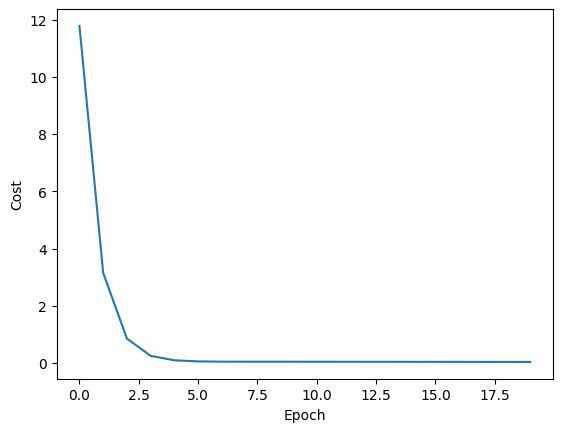

In [4]:
costs=[]
b0=0
b1=0

for epoch in range(20):

    for i in range(len(x)):

        pred=b0+b1*x[i]
        error=pred-y[i]

        b0-=lr*error
        b1-=lr*error*x[i]

    predictions=b0+b1*x
    cost=np.mean((predictions-y)**2)
    costs.append(cost)

plt.plot(costs)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()

# Q4 SGD vs Batch Gradient Descent

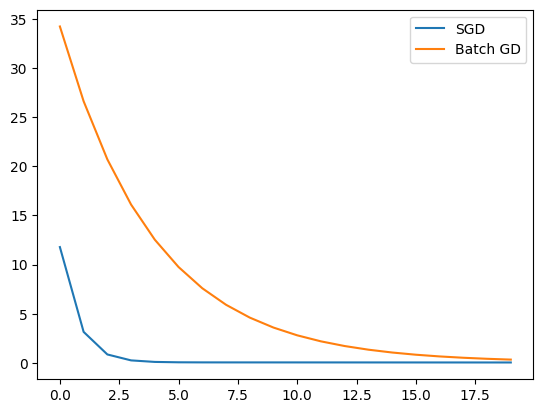

In [5]:
sgd=[]
bgd=[]

b0=b1=0

for e in range(20):

    for i in range(len(x)):
        pred=b0+b1*x[i]
        error=pred-y[i]

        b0-=lr*error
        b1-=lr*error*x[i]

    sgd.append(np.mean((b0+b1*x-y)**2))

b0=b1=0

for e in range(20):

    pred=b0+b1*x
    error=pred-y

    b0-=lr*np.mean(error)
    b1-=lr*np.mean(error*x)

    bgd.append(np.mean((b0+b1*x-y)**2))

plt.plot(sgd,label='SGD')
plt.plot(bgd,label='Batch GD')
plt.legend()
plt.show()

# Q5 Mini Batch Implementation

In [6]:
x=np.random.rand(100)
y=2*x+1+np.random.randn(100)*0.1

batch=10

b0=b1=0

for e in range(20):

    for i in range(0,100,batch):

        xb=x[i:i+batch]
        yb=y[i:i+batch]

        pred=b0+b1*xb

        error=pred-yb

        b0-=lr*np.mean(error)
        b1-=lr*np.mean(error*xb)

print(b0,b1)

1.4061310263227136 0.9304142709368385


# Q6 Batch Size Experiment

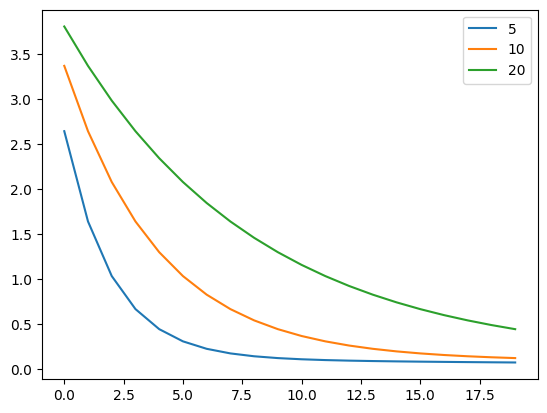

In [7]:
sizes=[5,10,20]

for batch in sizes:

    cost=[]
    b0=b1=0

    for e in range(20):

        for i in range(0,100,batch):

            xb=x[i:i+batch]
            yb=y[i:i+batch]

            pred=b0+b1*xb
            error=pred-yb

            b0-=lr*np.mean(error)
            b1-=lr*np.mean(error*xb)

        cost.append(np.mean((b0+b1*x-y)**2))

    plt.plot(cost,label=str(batch))

plt.legend()
plt.show()

# Q7 Shuffle vs No Shuffle

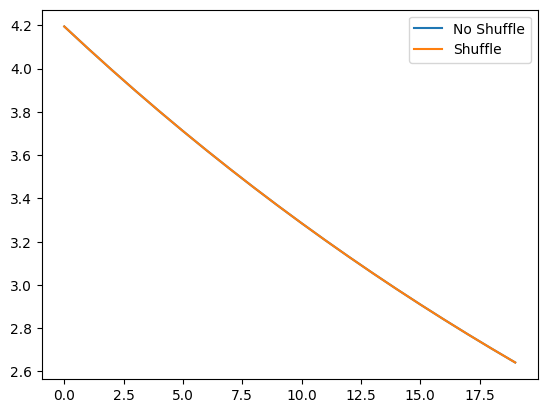

In [8]:
cost1=[]
cost2=[]

for shuffle in [False,True]:

    b0=b1=0
    temp=[]

    for e in range(20):

        if shuffle:
            idx=np.random.permutation(100)
            xs=x[idx]
            ys=y[idx]
        else:
            xs=x
            ys=y

        pred=b0+b1*xs
        err=pred-ys

        b0-=lr*np.mean(err)
        b1-=lr*np.mean(err*xs)

        temp.append(np.mean((b0+b1*x-y)**2))

    if shuffle:
        cost2=temp
    else:
        cost1=temp

plt.plot(cost1,label='No Shuffle')
plt.plot(cost2,label='Shuffle')
plt.legend()
plt.show()

# Q8 Real Dataset Simulation

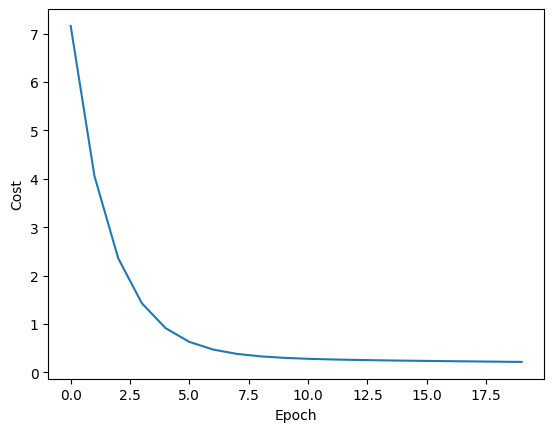

[1.60824278 1.30147591] 2.068452183297681


In [9]:
X=np.random.rand(200,2)

y=3*X[:,0]+2*X[:,1]+1+np.random.randn(200)*0.1

weights=np.zeros(2)
bias=0

cost=[]

for epoch in range(20):

    for i in range(0,200,10):

        xb=X[i:i+10]
        yb=y[i:i+10]

        pred=np.dot(xb,weights)+bias

        error=pred-yb

        weights-=lr*np.dot(xb.T,error)/len(xb)

        bias-=lr*np.mean(error)

    cost.append(np.mean((np.dot(X,weights)+bias-y)**2))

plt.plot(cost)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()

print(weights,bias)